# Import the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

import warnings
warnings.filterwarnings('ignore')

# Create a toy dataset

In [2]:
X = np.array([[1, 2], [2, 2], [2, 3], [8, 7], [8, 9], [25, 50]])

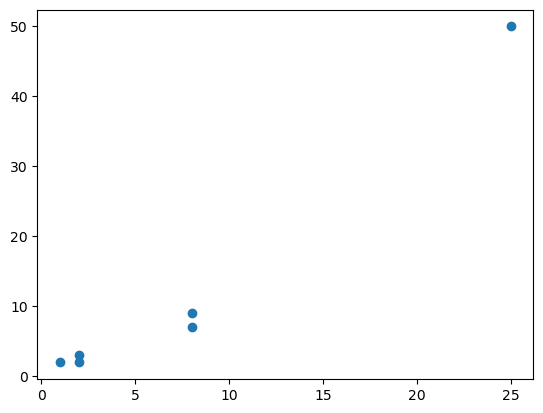

In [3]:
plt.scatter(X[:, 0], X[:, 1]);

# DBSCAN

## Toy Data

In [4]:
dbscan = DBSCAN(eps=5, min_samples=2)

In [5]:
dbscan.fit(X)

DBSCAN(eps=5, min_samples=2)

In [6]:
dbscan.labels_

array([ 0,  0,  0,  1,  1, -1])

* Three clusters formed. 
* [1, 2], [2, 2], [2, 3] - cluster 0
* [8, 7], [8, 9] - cluster 1
* [25, 50] - cluster -1
* DBSCAN assign -1 as cluster for noise points (outliers)

In [7]:
dbscan_ = DBSCAN(eps=5, min_samples=3)

In [8]:
dbscan_.fit(X)

DBSCAN(eps=5, min_samples=3)

In [9]:
dbscan_.labels_

array([ 0,  0,  0, -1, -1, -1])

* Since, min_samples is set as 3, points - [8, 7], [8, 8] did not become neither border point, not core point hence it labeled as noise points.

## Concentric Circles

In [10]:
X, _ = make_circles(n_samples=500, factor=.5, noise=.03, random_state=42)

In [11]:
# Apply DBSCAN to the dataset
dbscan_cc = DBSCAN(eps=0.1, min_samples=5)
clusters = dbscan_cc.fit_predict(X)
clusters

array([0, 1, 0, 1, 2, 0, 0, 2, 1, 0, 1, 1, 0, 3, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 2, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 2, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 3, 0, 0, 0, 0, 3, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 3, 0, 1, 0, 3, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 2,
       2, 0, 0, 1, 0, 0, 1, 1, 2, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2, 0, 1, 2,
       0, 0, 2, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 0, 1, 1, 0, 0, 1, 2, 1, 1,
       0, 0, 1, 1, 0, 1, 2, 0, 0, 1, 0, 0, 1, 1, 0, 2, 1, 1, 0, 2, 2, 1,
       0, 1, 2, 0, 0, 1, 0, 0, 0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 2, 1, 2, 2,
       2, 0, 0, 3, 1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 2, 0, 1, 0, 0, 1, 2, 3, 0, 1, 0, 0, 0, 1, 2, 1, 0, 1,
       0, 1, 0, 2, 3, 1, 0, 1, 0, 0, 0, 1, 0, 0, 2, 0, 2, 0, 0, 2, 0, 2,
       2, 1, 0, 2, 0, 2, 1, 1, 1, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 1, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0,

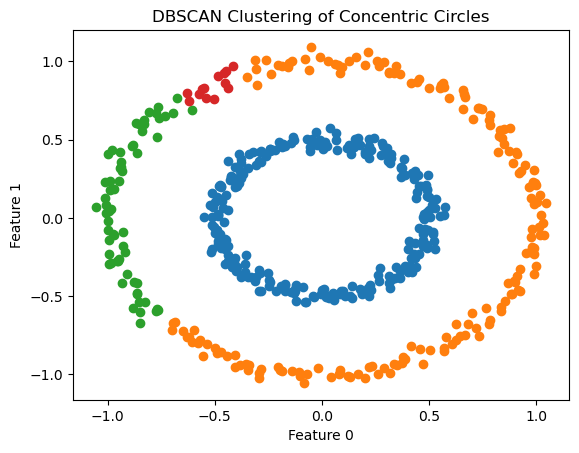

In [12]:
unique_clusters = np.unique(clusters)

for label in unique_clusters:
    mask = clusters == label
    
    if label == -1:
        plt.scatter(X[mask, 0], X[mask, 1], marker='x', label='Noise')
    else:
        plt.scatter(X[mask, 0], X[mask, 1], label=f'Cluster {label}')
        
plt.title("DBSCAN Clustering of Concentric Circles")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()